In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [3]:
x_test.shape

(10000, 32, 32, 3)

In [4]:
x_train.shape

(50000, 32, 32, 3)

In [5]:
y_train.shape

(50000, 1)

In [6]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [7]:
y_train =  y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [8]:
y_test = y_test.reshape(-1,)

In [9]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [10]:
def plot_sample(x, y, index):
    plt.figure(figsize=(15,2))
    plt.imshow(x[index])
    plt.xlabel(classes[y[index]])

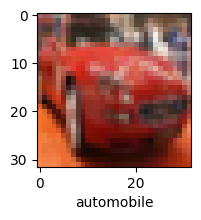

In [11]:
plot_sample(x_train, y_train, 5)

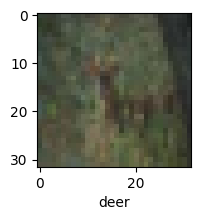

In [12]:
plot_sample(x_train, y_train, 10)

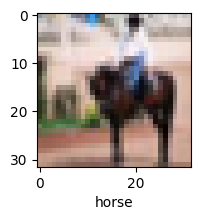

In [13]:
plot_sample(x_train, y_train, 11)

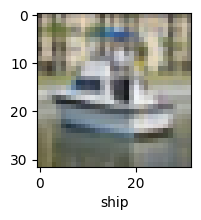

In [14]:
plot_sample(x_train, y_train, 501)

In [15]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
cnn_new = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_new.compile(optimizer='SGD',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn_new.fit(x_train, y_train, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 135s 86ms/step - accuracy: 0.3529 - loss: 1.8127
Epoch 2/5
 804/1563 ━━━━━━━━━━━━━━━━━━━━ 1:01 81ms/step - accuracy: 0.4222 - loss: 1.6510

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
y_pred = cnn_new.predict(x_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print('classification_report: \n ', classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step
classification_report: 
                precision    recall  f1-score   support

           0       0.49      0.58      0.53      1000
           1       0.67      0.47      0.56      1000
           2       0.49      0.17      0.25      1000
           3       0.33      0.41      0.37      1000
           4       0.51      0.35      0.41      1000
           5       0.39      0.37      0.38      1000
           6       0.53      0.55      0.54      1000
           7       0.54      0.55      0.54      1000
           8       0.50      0.72      0.59      1000
           9       0.48      0.67      0.56      1000

    accuracy                           0.48     10000
   macro avg       0.49      0.48      0.47     10000
weighted avg       0.49      0.48      0.47     10000



In [ ]:
import seaborn as sns

<function matplotlib.pyplot.show(close=None, block=None)>

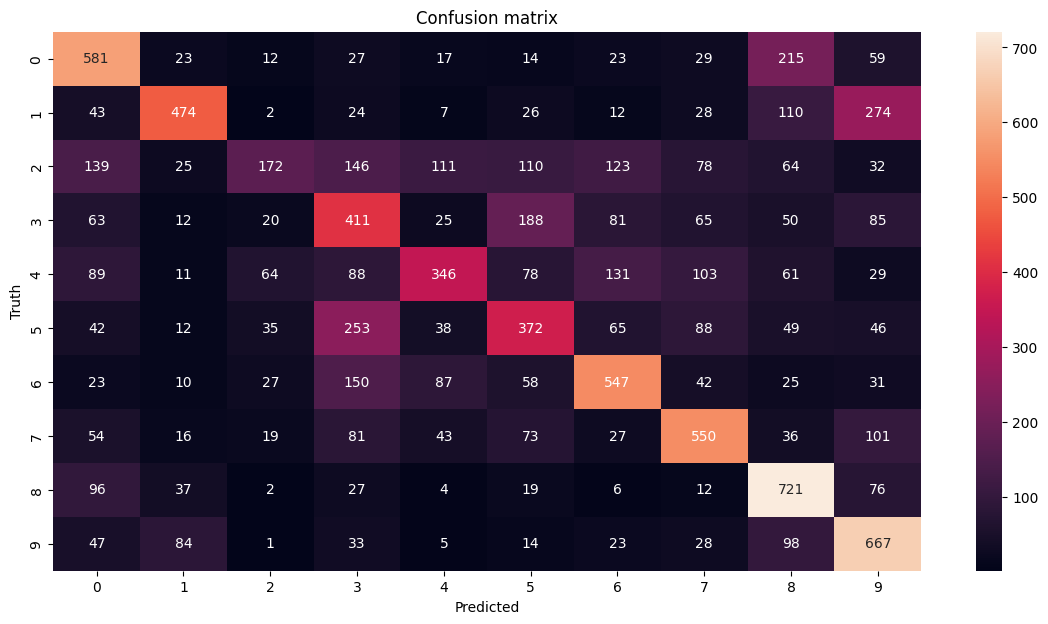

In [ ]:
plt.figure(figsize=(14,7))
sns.heatmap(confusion_matrix(y_test, y_pred_classes), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Confusion matrix')
plt.show

In [ ]:
cnn_new = models.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn_new.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

In [ ]:
cnn_new.fit(x_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 47ms/step - accuracy: 0.4777 - loss: 1.4489
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.6129 - loss: 1.1037
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 91s 58ms/step - accuracy: 0.6573 - loss: 0.9844
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 133s 52ms/step - accuracy: 0.6863 - loss: 0.9004
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 92s 59ms/step - accuracy: 0.7102 - loss: 0.8312
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 119s 44ms/step - accuracy: 0.7317 - loss: 0.7723
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 44ms/step - accuracy: 0.7494 - loss: 0.7186
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 44ms/step - accuracy: 0.7640 - loss: 0.6731
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.7792 - loss: 0.6316
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 44ms/step - accuracy: 0.7931 - loss: 0.5907


In [ ]:
cnn_new.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6945 - loss: 0.9562


[0.9561940431594849, 0.6945000290870667]

In [ ]:
y_pred = cnn_new.predict(x_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


array([[5.00994250e-02, 1.37141338e-04, 1.42881740e-03, 5.48910022e-01,
        7.05215032e-04, 3.82885814e-01, 1.73618947e-03, 9.62942649e-05,
        1.32612344e-02, 7.39709532e-04],
       [7.71875668e-04, 1.64018348e-02, 2.79448837e-08, 1.01731255e-08,
        1.04338191e-08, 7.59415641e-10, 2.54206396e-11, 2.99128011e-08,
        9.81476367e-01, 1.34981377e-03],
       [7.79668801e-03, 1.72632579e-02, 3.84266496e-05, 2.85144488e-04,
        4.12100926e-05, 1.74436369e-04, 1.21172184e-06, 6.74388066e-05,
        9.71215308e-01, 3.11683328e-03],
       [9.58518624e-01, 1.45354506e-03, 6.65154366e-05, 4.98055248e-04,
        4.16362454e-05, 2.26895691e-06, 8.10828624e-06, 5.45093681e-05,
        3.31378393e-02, 6.21888507e-03],
       [1.84757141e-06, 7.42577613e-05, 2.89707743e-02, 2.68898420e-02,
        6.07443333e-01, 4.43255045e-02, 2.90960312e-01, 2.34209324e-06,
        1.33107137e-03, 8.24187680e-07]], dtype=float32)

In [ ]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(4)]

In [ ]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

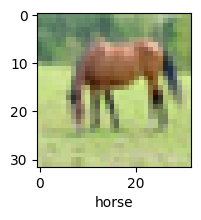

In [ ]:
plot_sample(x_test, y_test, 60)

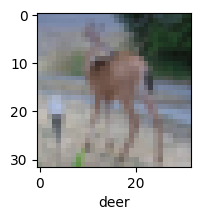

In [ ]:
plot_sample(x_test, y_test, 100)

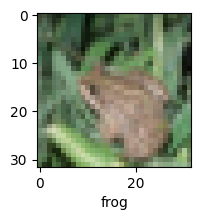

In [ ]:
plot_sample(x_test, y_test, 4)

In [ ]:
classes[y_classes[4]]

'deer'

In [ ]:
classes[y_classes[60]]

'horse'